# foraois demo

An interactive walkthrough of foraois: cosmology setup, the three
merger-tree backends, the built-in visualisations, and the branching-rate
validation tools in `foraois.diagnostics`.

This notebook uses CAMB for the linear power spectrum
(`pip install foraois[camb]`, config: `config/planck2018_camb.yml`);
CLASS is an equally valid alternative (`mode: class`, see the README and
`config/planck2018.yml`).


In [1]:
import numpy as np

from foraois import diagnostics
from foraois.cosmo_utils import CosmoData
from foraois.pch_trees import PCHMergerTree
from foraois.utils import io, plot

np.random.seed(42)

## 1. Cosmology setup

`CosmoData` wraps CAMB/CLASS to build the linear power spectrum, then
precomputes `sigma(M)` and `delta_col(z)` lookup tables that
`PCHMergerTree` consumes.


In [2]:
run_params = io.get_params("../config/planck2018_camb.yml")
cosmo_data = CosmoData(run_params, redshift=[0.0])
pk_data = cosmo_data.get_power_spectrum()

print(f"h = {cosmo_data.cosmo_params['h']:.4f}")

h = 0.6756


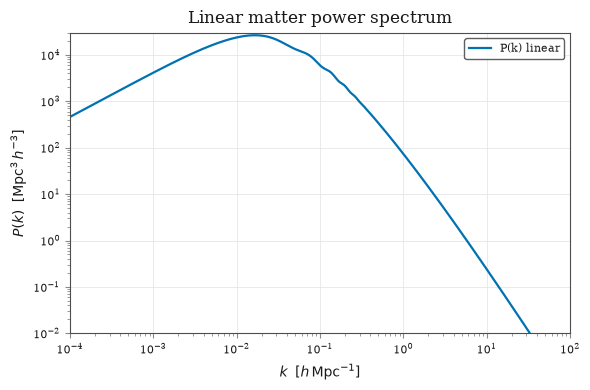

In [3]:
plot.plot_power_spectrum(
    pk_data,
    file_name=None,
    axes_limits={"xmin": 1e-4, "xmax": 1e2, "ymin": 1e-2, "ymax": 3e4},
)

sigma_8 = 0.8487


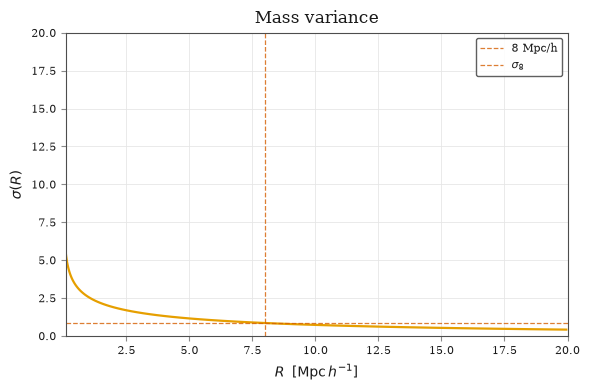

In [4]:
cosmo_data.sigma8 = cosmo_data.get_mass_variance(
    pk_data, radius=8.0, window_function_type="top_hat"
)
print(f"sigma_8 = {np.sqrt(cosmo_data.sigma8):.4f}")

plot.plot_mass_variance(
    cosmo_data,
    pk_data,
    file_name=None,
    axes_limits={"xmin": 0.1, "xmax": 20.0, "ymin": 0.0, "ymax": 20.0},
)

## 2. A single tree (serial, for inspection)

`build_tree` grows one halo backward in time using the Appendix A
branching-rate algorithm (Parkinson, Cole & Helly 2008) -- useful for
looking at what an individual merger history looks like, and as the
reference the vectorised backends below are checked against.


80 recorded branching events


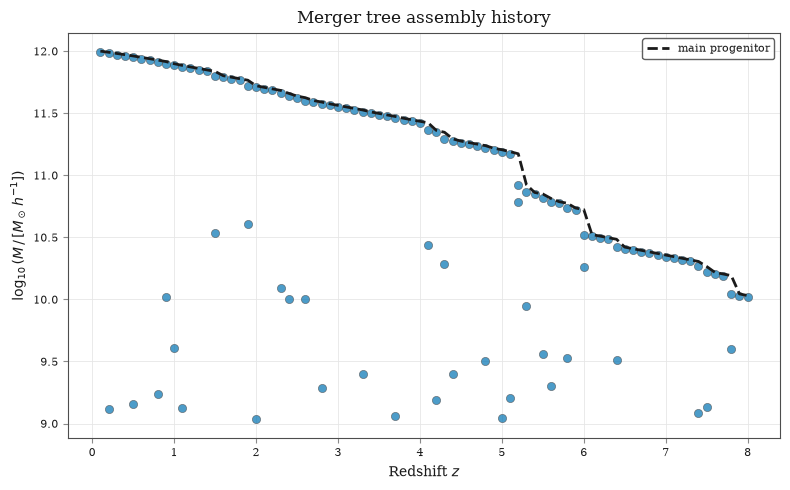

In [5]:
tree_generator = PCHMergerTree(cosmo_data, run_params)

M0, z0, z_max, M_res, dz = 1.0e12, 0.0, 8.0, 1.0e9, 0.1
tree = tree_generator.build_tree(M0=M0, z0=z0, z_max=z_max, M_res=M_res, dz=dz)
print(f"{len(tree)} recorded branching events")

plot.plot_merger_history(tree, file_name=None)

## 3. A forest of trees (vectorised)

`build_forest_numpy` evolves every tree through the same redshift grid
simultaneously -- no Numba required, ~100-1000x faster than calling
`build_tree` N times.

`dz` here is deliberately chosen small enough that the step-size
diagnostic in §5 below confirms it's safe for this halo mass -- see that
section for why this matters and what happens if `dz` is too coarse.


In [6]:
N = 10_000
M0_array = np.full(N, 1.0e12)

mass_history, split_events, z_steps, smooth_accretion, merger_mass = (
    tree_generator.build_forest_numpy(
        M0_array=M0_array,
        z0=0.0,
        z_max=3.0,
        M_res=1.0e9,
        dz=0.005,
    )
)
print(f"mass_history shape: {mass_history.shape}")
print(f"total merger events recorded: {sum(e['n_splits'] for e in split_events):,}")

mass_history shape: (10000, 600)
total merger events recorded: 555,253


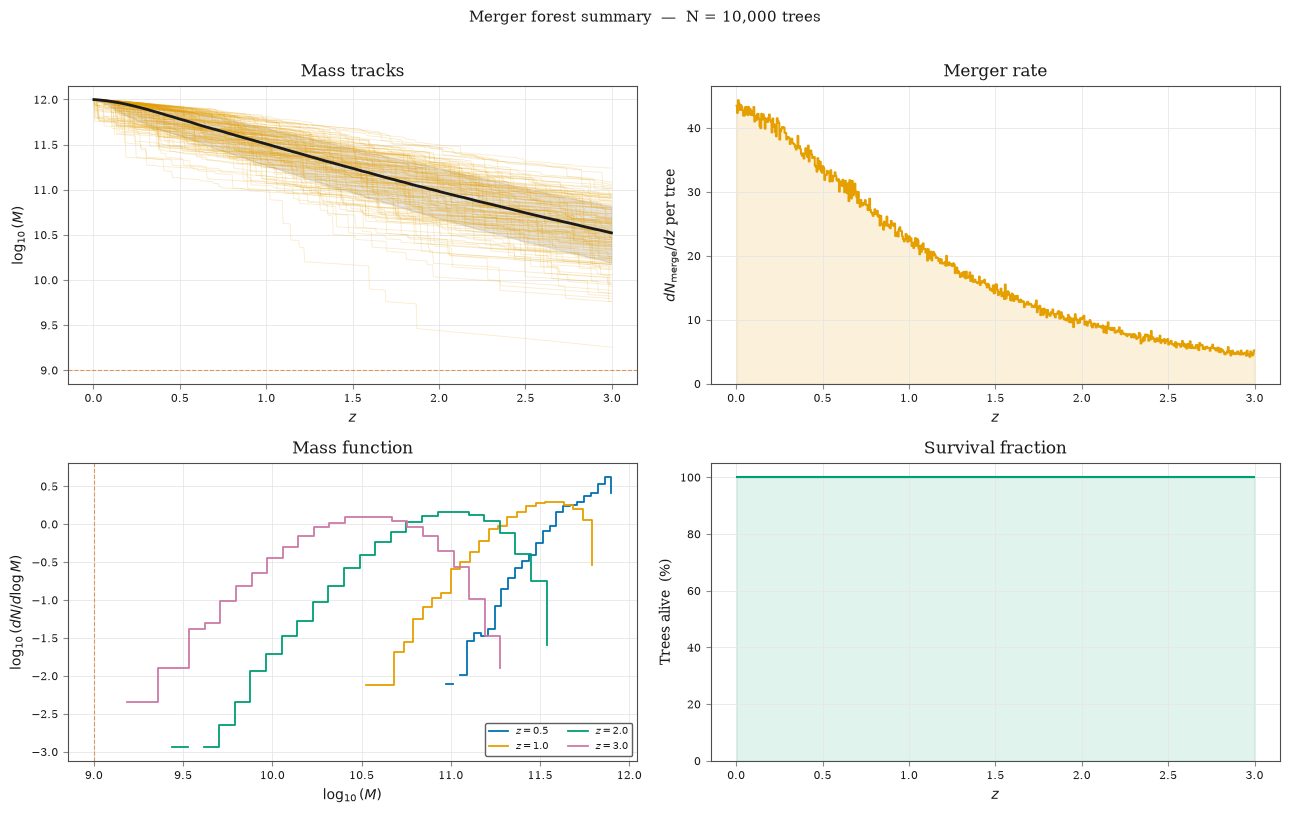

In [7]:
plot.plot_forest_summary(
    mass_history,
    split_events,
    z_steps,
    M_res=1.0e9,
    n_show=150,
    file_name=None,
)

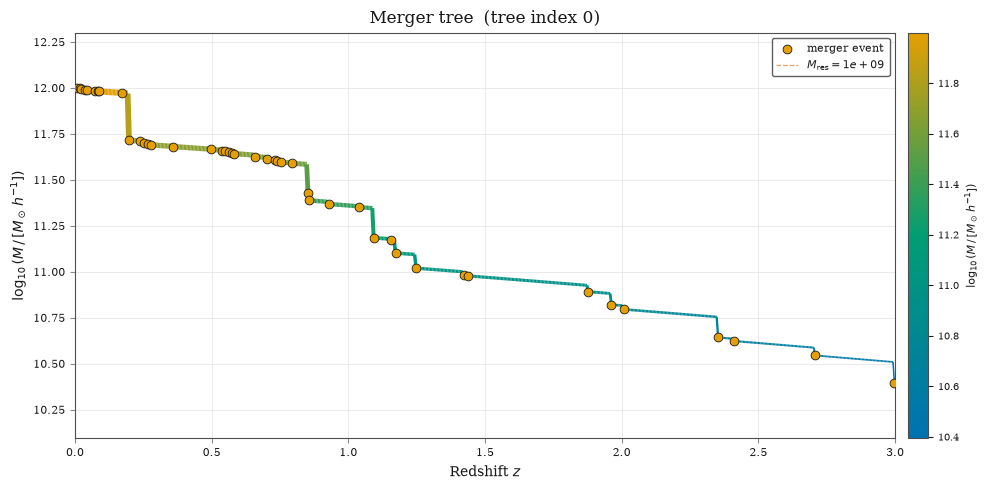

In [8]:
plot.plot_tree_graph(
    mass_history,
    z_steps,
    tree_idx=0,
    M_res=1.0e9,
    split_events=split_events,
    file_name=None,
)

## 3b. The full branching structure, and a publication-style tree diagram

`build_forest_numpy`/`build_forest_numba` (and `plot_tree_graph` above) only
track the *main* progenitor branch -- exactly what you want for a large
statistical sample, but not what a merger-tree diagram like Nadler et al.
(2023), Figure 4 shows, which draws every branch fanning out from the root.

`build_full_tree` grows every branch recursively down to `M_res` for a
single tree (this doesn't vectorise across haloes the way the other
backends do -- the branching structure itself is the point), and
`plot_dendrogram` draws it: node size ~ log(mass), edge length ~ log(elapsed
cosmic time) between a node and its descendant (so the tree visibly
compresses at high z, where a fixed `dz` spans much less cosmic time), main
branch highlighted.

Real trees vary a lot in how much branching structure survives a given
mass-display cut (steep mass functions mean major mergers are genuinely
rare in any single random realization) -- picking a nice illustrative
example is normal practice, not cherry-picking away a bug; we just scan a
handful of seeds here for one with visible structure.


In [9]:
best_seed, best_n_visible, best_nodes = None, -1, None
for seed in range(20):
    np.random.seed(seed)
    nodes = tree_generator.build_full_tree(
        M0=1e14,
        z0=0.0,
        z_max=15.0,
        M_res=1e9,
        dz=0.1,
        max_nodes=50_000,
    )
    by_desc = {}
    for n in nodes:
        by_desc.setdefault(n["descendant_id"], []).append(n)
    n_visible = sum(
        1
        for kids in by_desc.values()
        if len(kids) == 2 and all(k["mass"] >= 1e11 for k in kids)
    )
    if n_visible > best_n_visible:
        best_seed, best_n_visible, best_nodes = seed, n_visible, nodes

print(
    f"best seed: {best_seed} ({best_n_visible} branch points with both children >= 1e11 Msun/h, "
    f"{len(best_nodes):,} total nodes down to M_res=1e9)"
)

best seed: 14 (4 branch points with both children >= 1e11 Msun/h, 313 total nodes down to M_res=1e9)


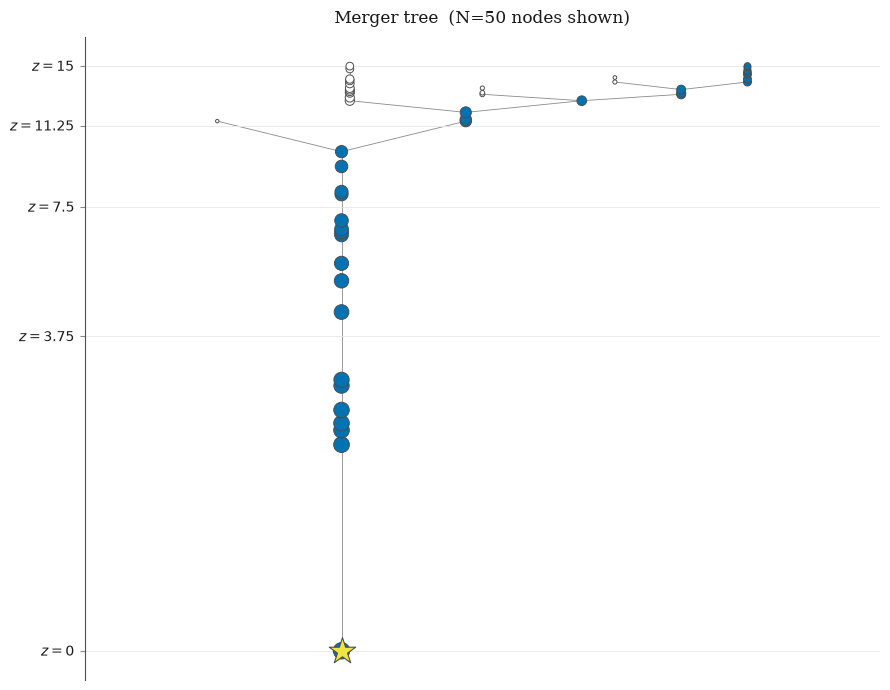

In [10]:
plot.plot_dendrogram(
    best_nodes,
    cosmo_data,
    M_min_display=1e11,
    mark_node_id=0,
    file_name=None,
)

## 3c. The excursion-set view: Delta_delta vs Delta_S

A halo's mass at each recorded redshift is, by construction, exactly
where its excursion-set random walk first crosses the collapse barrier
`delta_c(z)` at that redshift -- so a tree's own (M, z) history already
*is* a walk in the `(S, delta)` plane, where `S = sigma(M)^2` is the mass
variance. This re-expresses the tree_idx=0 trajectory from §3 above
that way, alongside the more familiar M vs z view, in the style of
Nadler et al. (2023), Figure 1's grey unconstrained-excursion line.

(Their coloured lines are *constrained* Brownian-bridge excursions,
forced through a specific `(M1, z1)` -- foraois doesn't implement that
yet, so there's nothing to draw for those here.)


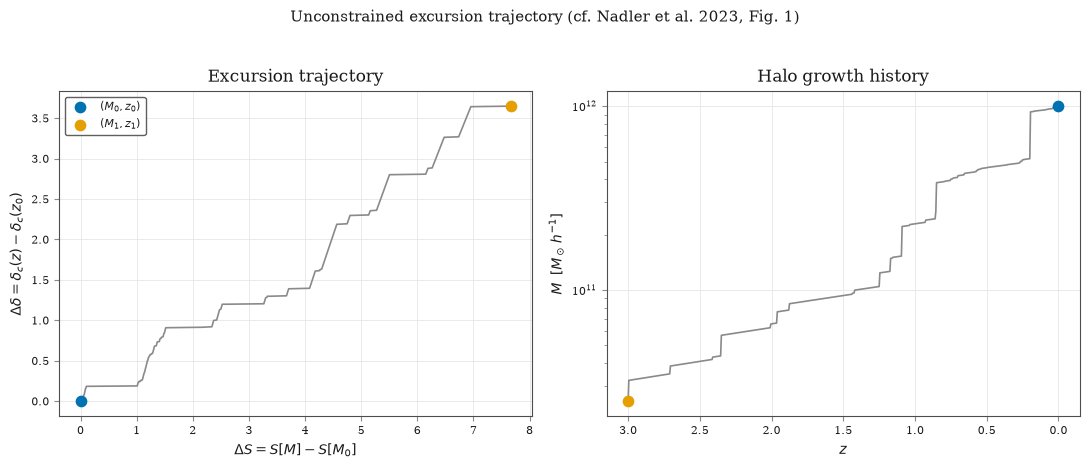

In [11]:
tree_idx = 0
masses = np.concatenate([[M0_array[tree_idx]], mass_history[tree_idx]])
redshifts = z_steps

plot.plot_excursion_trajectory(masses, redshifts, cosmo_data, file_name=None)

## 4. Backend comparison: NumPy vs Numba

Same algorithm, three implementations (`build_tree` serial,
`build_forest_numpy` vectorised, `build_forest_numba` JIT + parallel).
The first Numba call pays a one-off JIT compilation cost; subsequent
calls are typically 8-32x faster than the NumPy backend for large N.


In [12]:
import time

# warm up the JIT
tree_generator.build_forest_numba(
    np.full(10, 1e12), z0=0.0, z_max=1.0, M_res=1e9, dz=0.1
)

t0 = time.perf_counter()
mh_np, _, _, _, _ = tree_generator.build_forest_numpy(
    M0_array, z0=0.0, z_max=3.0, M_res=1.0e9, dz=0.005
)
t_np = time.perf_counter() - t0

t0 = time.perf_counter()
mh_nb, _, _, _ = tree_generator.build_forest_numba(
    M0_array, z0=0.0, z_max=3.0, M_res=1.0e9, dz=0.005
)
t_nb = time.perf_counter() - t0

print(f"numpy: {t_np:.3f} s   numba: {t_nb:.3f} s   speedup: {t_np / t_nb:.1f}x")

frac_np = np.mean(mh_np[:, -1] > 0)
frac_nb = np.mean(mh_nb[:, -1] > 0)
print(f"fraction resolved at z_max -- numpy: {frac_np:.3f}   numba: {frac_nb:.3f}")

numpy: 4.726 s   numba: 0.742 s   speedup: 6.4x
fraction resolved at z_max -- numpy: 1.000   numba: 1.000


## 5. Validating the branching-rate machinery (`foraois.diagnostics`)

`PCHMergerTree` implements the exact Parkinson, Cole & Helly (2008)
Appendix A algorithm, but with one deliberate simplification: PCH08's own
algorithm *adaptively* shrinks the step size per halo to keep the
expected number of splits per step (`Nupper`) small; this implementation
uses a single **fixed** `dz` shared across an entire forest instead,
because that shared grid is what makes the vectorised backends possible.

That means `Nupper` isn't bounded small by construction -- it's worth
checking it stays below 1 (PCH08's own target: roughly 0.1) for whatever
`dz` you choose, especially for large haloes or coarse steps. Above 1 the
single-split-per-step model breaks down: comparing a single `r1` against
`Nupper` is implicitly clipped at a probability of 1, silently
*underestimating* the true (unclipped) merger rate.


In [13]:
z_diag, Nupper_coarse, _ = diagnostics.expected_splits_per_step(
    tree_generator,
    M0=1e12,
    z0=0.0,
    z_max=3.0,
    M_res=1e9,
    dz=0.2,
)
z_diag_fine, Nupper_fine, _ = diagnostics.expected_splits_per_step(
    tree_generator,
    M0=1e12,
    z0=0.0,
    z_max=3.0,
    M_res=1e9,
    dz=0.005,
)

print(
    f"dz=0.2:   max Nupper = {np.nanmax(Nupper_coarse):.3f}   (too coarse for this halo)"
)
print(
    f"dz=0.005: max Nupper = {np.nanmax(Nupper_fine):.3f}   (the dz used in \u00a73 above)"
)

dz=0.2:   max Nupper = 24.422   (too coarse for this halo)
dz=0.005: max Nupper = 0.575   (the dz used in §3 above)


The second, independent check: `Nupper` is only an *upper bound* on the
true split probability (it's the integral of the majorising envelope, not
the target density itself). `check_sampling_consistency` runs the actual
rejection-sampling code path via Monte Carlo and compares the accepted
rate against an independently-computed quadrature integral of the true
target density `S(q)*R(q)` -- this validates the sampler against an
external reference, not just against itself. It refuses to run at all
when `Nupper >= 1`, since the comparison isn't meaningful in that regime
(see the cell above and its `ValueError` below).


In [14]:
result = diagnostics.check_sampling_consistency(
    tree_generator,
    M2=1e12,
    M_res=1e9,
    delta0=1.68,
    d_omega=0.002,
    n_trials=300_000,
    seed=0,
)
result

{'empirical_rate': 0.09798,
 'true_rate': 0.09778024924567247,
 'n_sigma': 0.368355637028156,
 'passed': True}

In [15]:
# And here's what happens if you try to run the same check somewhere
# Nupper >= 1 (the "dz=0.2" case flagged above) -- a clear error instead of
# a confusing silent discrepancy:
try:
    diagnostics.check_sampling_consistency(
        tree_generator,
        M2=1e12,
        M_res=1e9,
        delta0=1.68,
        d_omega=0.2,
        n_trials=1000,
    )
except ValueError as exc:
    print(f"ValueError: {exc}")

ValueError: Nupper = 25.973 >= 1 for this (M2, M_res, delta0, d_omega): the single-split-per-step approximation has broken down here (see expected_splits_per_step), so comparing against true_split_probability isn't a meaningful check -- reduce dz (i.e. d_omega) for this halo/step before trusting build_forest_* output, and re-run this check with the smaller d_omega.


## 6. Non-standard dark matter: WDM

Everything above is CDM. Switching to warm dark matter (WDM) only means
building a *different* `CosmoData` -- `dm_model: wdm` (plus a particle
mass in keV) in the config multiplies the linear `P(k)` by a thermal-relic
transfer function (Viel et al. 2005) before anything else touches it.
`PCHMergerTree` itself never changes: its kernels only ever consume
`sigma(M)`/`delta_col(z)` through `CosmoData`'s lookup tables, never `P(k)`
directly, so WDM support required zero changes to the tree-building code.


In [16]:
run_params_wdm = io.get_params("../config/planck2018_wdm.yml")
cosmo_data_wdm = CosmoData(run_params_wdm, redshift=[0.0])
pk_data_wdm = cosmo_data_wdm.get_power_spectrum()
cosmo_data_wdm._prepare_sigma_grid(pk_data_wdm)

print(
    f"dm_model={run_params_wdm['Code']['dm_model']}, "
    f"m_wdm={run_params_wdm['Code']['dm_model_mass']} keV"
)

dm_model=wdm, m_wdm=3.0 keV


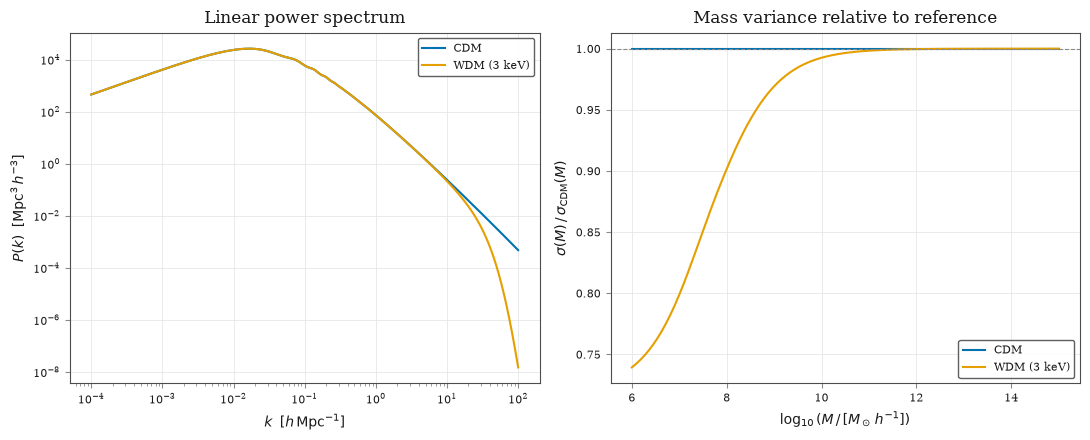

In [17]:
cosmo_data._prepare_sigma_grid(
    pk_data
)  # (re-)build the CDM grid too, for the comparison

plot.plot_dm_model_comparison(
    {"CDM": (cosmo_data, pk_data), "WDM (3 keV)": (cosmo_data_wdm, pk_data_wdm)},
    reference="CDM",
    file_name=None,
)

The suppression is exactly where it should be: `sigma(M)` matches CDM
above ~$10^{11}\,M_\odot h^{-1}$ and drops off below the WDM free-streaming
scale. Building a forest with this `CosmoData` uses the exact same
`build_forest_numpy`/`build_forest_numba` calls as every CDM example
above -- nothing else changes.


WDM forest built: (5000, 250), 99.6% resolved at z_max


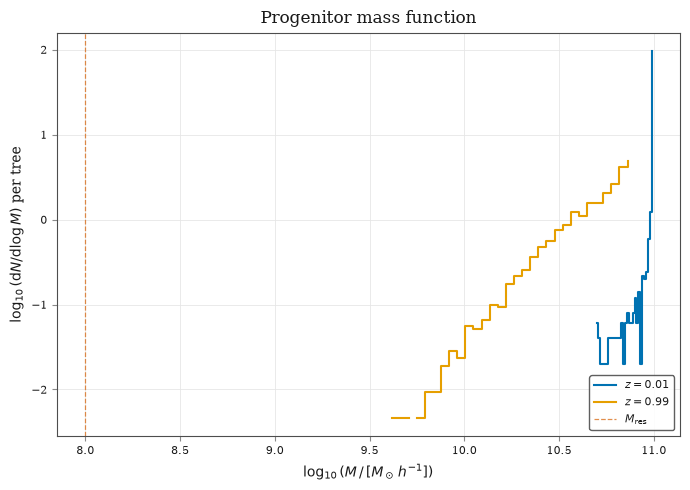

In [18]:
tree_generator_wdm = PCHMergerTree(cosmo_data_wdm, run_params_wdm)

np.random.seed(0)
mass_history_wdm, _, z_steps_wdm, _, _ = tree_generator_wdm.build_forest_numpy(
    M0_array=np.full(5_000, 1.0e11),
    z0=0.0,
    z_max=5.0,
    M_res=1.0e8,
    dz=0.02,
)
print(
    f"WDM forest built: {mass_history_wdm.shape}, "
    f"{np.mean(mass_history_wdm[:, -1] > 0):.1%} resolved at z_max"
)

plot.plot_mass_function(
    mass_history_wdm,
    z_steps_wdm,
    z_targets=[0.0, 1.0],
    M_res=1.0e8,
    file_name=None,
)

## 7. Non-standard dark matter: FDM

Fuzzy/scalar-field dark matter (FDM) plugs in exactly the same way as WDM:
`dm_model: fdm` (plus a particle mass in units of $10^{-22}$ eV) multiplies
the linear `P(k)` by the Hu, Barkana & Gruzinov (2000) transfer function
before anything else touches it. `PCHMergerTree` again needs zero changes.

Note this only captures FDM's *linear* suppression of `P(k)` -- the same
quantum pressure that produces this cutoff also keeps acting during
nonlinear collapse (soliton cores, a genuine minimum halo mass), which
would need a mass-dependent collapse barrier $\delta_c(M)$ to capture
properly. That's a separate, harder research question (see
`transfer_functions.py`'s module docstring) and isn't attempted here.


In [19]:
run_params_fdm = io.get_params("../config/planck2018_fdm.yml")
cosmo_data_fdm = CosmoData(run_params_fdm, redshift=[0.0])
pk_data_fdm = cosmo_data_fdm.get_power_spectrum()
cosmo_data_fdm._prepare_sigma_grid(pk_data_fdm)

print(
    f"dm_model={run_params_fdm['Code']['dm_model']}, "
    f"m_a22={run_params_fdm['Code']['dm_model_mass']} (1e-22 eV)"
)

dm_model=fdm, m_a22=1.0 (1e-22 eV)


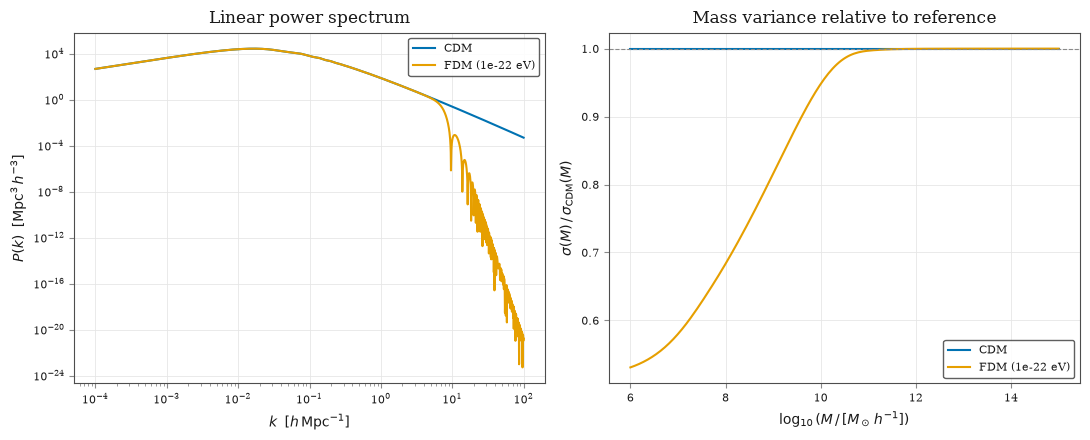

In [20]:
plot.plot_dm_model_comparison(
    {"CDM": (cosmo_data, pk_data), "FDM (1e-22 eV)": (cosmo_data_fdm, pk_data_fdm)},
    reference="CDM",
    file_name=None,
)

As with WDM, `sigma(M)` matches CDM at high mass and cuts off below the
FDM suppression scale -- but the cutoff is sharper here, since $T_{FDM}(k)$
falls off faster than $T_{WDM}(k)$ at fixed half-mode scale. Building a
forest uses the same `build_forest_numpy`/`build_forest_numba` calls as
every other example in this notebook.


FDM forest built: (5000, 250), 84.3% resolved at z_max


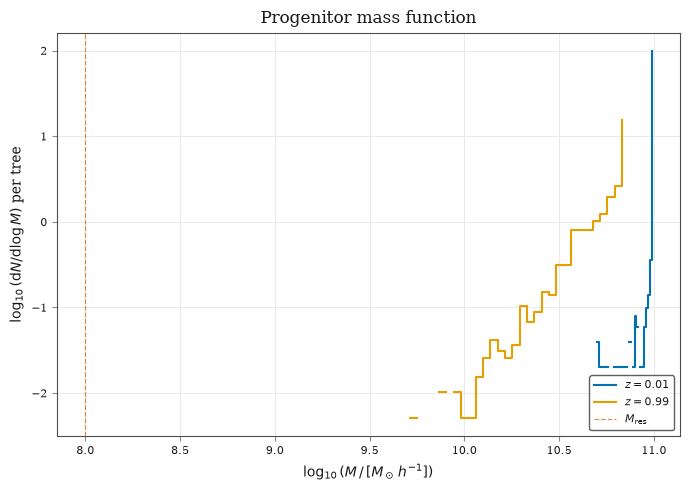

In [21]:
tree_generator_fdm = PCHMergerTree(cosmo_data_fdm, run_params_fdm)

np.random.seed(0)
mass_history_fdm, _, z_steps_fdm, _, _ = tree_generator_fdm.build_forest_numpy(
    M0_array=np.full(5_000, 1.0e11),
    z0=0.0,
    z_max=5.0,
    M_res=1.0e8,
    dz=0.02,
)
print(
    f"FDM forest built: {mass_history_fdm.shape}, "
    f"{np.mean(mass_history_fdm[:, -1] > 0):.1%} resolved at z_max"
)

plot.plot_mass_function(
    mass_history_fdm,
    z_steps_fdm,
    z_targets=[0.0, 1.0],
    M_res=1.0e8,
    file_name=None,
)

## 8. The sharp-k window function

Everything above uses the default real-space top-hat window for sigma(M).
For WDM/FDM specifically, the literature (Benson et al. 2013 for WDM;
Kulkarni & Ostriker 2022 for FDM) instead recommends a sharp-k
(Fourier-space step-function) window: $W(k,R) = 1$ for $k \le k_0 = \alpha/R$,
$0$ otherwise, with $\alpha = 2.5$. The top-hat's oscillatory
$\sin(x)/x$-like tails let small-scale power leak back in above the
free-streaming/quantum-pressure cutoff (the "cloud-in-cloud" artifact);
sharp-k removes that power exactly instead of just damping it.

This is set via `window_function_type: sharp_k` in a config's `Run` section
(see `config/planck2018_fdm_sharpk.yml`, which pairs it with the same FDM
model used in section 7) -- `CosmoData` and `PCHMergerTree` need no other
changes; `dlogsigma_dlogmass` has its own closed-form derivative for the
sharp-k case internally (its window is discontinuous, so the generic
numerical-derivative route used for top-hat/Gaussian doesn't apply), but
that's transparent to any caller.


In [22]:
run_params_fdm_sharpk = io.get_params("../config/planck2018_fdm_sharpk.yml")
cosmo_data_fdm_sharpk = CosmoData(run_params_fdm_sharpk, redshift=[0.0])
pk_data_fdm_sharpk = cosmo_data_fdm_sharpk.get_power_spectrum()
cosmo_data_fdm_sharpk._prepare_sigma_grid(pk_data_fdm_sharpk)

print(
    f"window_function_type={cosmo_data_fdm_sharpk.window_function_type}, "
    f"sharp_k_alpha={cosmo_data_fdm_sharpk.wf.sharp_k_alpha}"
)

window_function_type=sharp_k, sharp_k_alpha=2.5


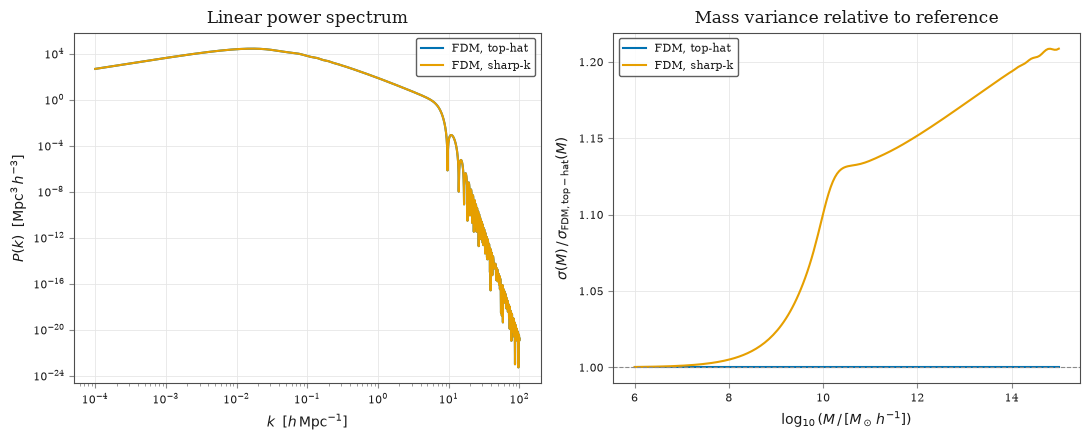

In [23]:
plot.plot_dm_model_comparison(
    {
        "FDM, top-hat": (cosmo_data_fdm, pk_data_fdm),
        "FDM, sharp-k": (cosmo_data_fdm_sharpk, pk_data_fdm_sharpk),
    },
    reference="FDM, top-hat",
    file_name=None,
)

Same underlying FDM power spectrum both times -- only the window function
differs. sigma(M) is systematically larger for sharp-k at fixed mass (it
counts every mode up to the cutoff with equal weight, whereas top-hat's
tails partially suppress modes near the cutoff), consistent with
Kulkarni & Ostriker 2022's Figure 2. Building a forest again needs no
changes beyond the `CosmoData` setup above.


In [24]:
tree_generator_fdm_sharpk = PCHMergerTree(cosmo_data_fdm_sharpk, run_params_fdm_sharpk)

# M_res is well above the FDM+sharp-k suppression scale here, unlike the
# top-hat FDM demo's M_res=1e8 -- sharp-k's abrupt cutoff (plus T_FDM's
# cos(x^3) ringing right at the cutoff) makes sigma(M) genuinely flat
# there, which the underlying PCH08 branching-rate algebra (V_res, V_half
# assume sigma strictly decreases with mass) isn't robust to. Physically
# this is also the right call regardless: a resolution mass inside a
# regime the model says can barely form halos at all isn't a meaningful
# thing to resolve trees down to.
np.random.seed(0)
mass_history_fdm_sharpk, _, z_steps_fdm_sharpk, _, _ = (
    tree_generator_fdm_sharpk.build_forest_numpy(
        M0_array=np.full(5_000, 1.0e12),
        z0=0.0,
        z_max=5.0,
        M_res=3.0e10,
        dz=0.02,
    )
)
print(
    f"FDM (sharp-k) forest built: {mass_history_fdm_sharpk.shape}, "
    f"{np.mean(mass_history_fdm_sharpk[:, -1] > 0):.1%} resolved at z_max"
)

FDM (sharp-k) forest built: (5000, 250), 14.0% resolved at z_max


## 9. Reproducing Figure 1 of Menon & Power (2024)

[Menon & Power 2024](https://ui.adsabs.harvard.edu/abs/2024PASA...41...49M/abstract) (PASA, 41, e049), Figure 1, shows the mass-assembly history of a statistical sample of 100 dark matter halos with $M_0 = 10^8\,M_\odot$ at $z=5$, generated with the PCH08 algorithm: halo mass and halo mass accretion rate vs. cosmic time (with a redshift twin axis), each panel showing the 100 individual trajectories in grey plus the running median and 10th/90th percentiles in red.

Cosmology used by the paper (their Sec. 2.1, stated as their Planck 2018 values): $\Omega_b=0.0484$, $\Omega_m=0.308$, $\Omega_\Lambda=0.692$, $h=0.678$, $\sigma_8=0.815$, $n_s=0.968$ -- matched here via `../config/menon_power_2024.yml` (CAMB `As` was solved for numerically so that $\sigma_8(z=0)=0.815$ exactly; see the comments in that file).

Two disclosed methodological differences from the paper:

- The paper samples redshift steps "equally spaced in the logarithm of the expansion factor $a=1/(1+z)$" over $5 \le z \le 25$. This reproduction instead uses foraois' native fine, uniform-in-$z$ stepping ($dz=0.01$) over the same range -- a denser, if differently spaced, sampling of the same interval.
- Below the tree's mass resolution `M_res`, `build_forest_numba` cannot resolve further branching and holds a progenitor's mass frozen at its last-resolved value rather than tracing it back further. That frozen segment is physically meaningless (it's an artifact of the resolution limit, not evidence the halo stopped growing), so each halo's trajectory is masked/starts only from its own first-resolved timestep below -- for $M_0=10^8\,M_\odot$ halos this resolution limit is reached at $z\approx14$ regardless of how small `M_res` is set (tried down to $10\,h^{-1}M_\odot$), consistent with these being small, late-forming objects whose EPS-predicted progenitor mass is already negligible that far back.

In [25]:
MPC_KM = 3.0856775814913673e19  # km per Mpc
GYR_S = 3.1556952e16  # s per Julian Gyr
T_RAW_TO_GYR = MPC_KM / GYR_S  # cosmic_time_at_z() returns time in units of Mpc/(km/s)

run_params_mp24 = io.get_params("../config/menon_power_2024.yml")
h_mp24 = run_params_mp24["Cosmology"]["H0"] / 100.0
cosmo_data_mp24 = CosmoData(run_params_mp24, redshift=[5.0])
tree_generator_mp24 = PCHMergerTree(cosmo_data_mp24, run_params_mp24)

N_HALOS_MP24 = 100
M0_hunits = np.full(N_HALOS_MP24, 1e8 * h_mp24)

np.random.seed(42)
mass_history, z_steps, smooth_accretion, merger_mass = (
    tree_generator_mp24.build_forest_numba(
        M0_array=M0_hunits,
        z0=5.0,
        z_max=25.0,
        M_res=10.0 * h_mp24,
        dz=0.01,
    )
)
mass_hunits = np.concatenate([M0_hunits[:, None], mass_history], axis=1)

# reverse to chronological order (ascending cosmic time = descending z)
order = np.argsort(z_steps)[::-1]
z_chron = z_steps[order]
mass_chron_msun = mass_hunits[:, order] / h_mp24
t_chron = cosmo_data_mp24.cosmic_time_at_z(z_chron) * T_RAW_TO_GYR  # Gyr

print(
    f"{N_HALOS_MP24} trees built; t = {t_chron[0]:.3f}-{t_chron[-1]:.3f} Gyr "
    f"(z = {z_chron[0]:.0f}-{z_chron[-1]:.0f})"
)

100 trees built; t = 0.131-1.177 Gyr (z = 25-5)


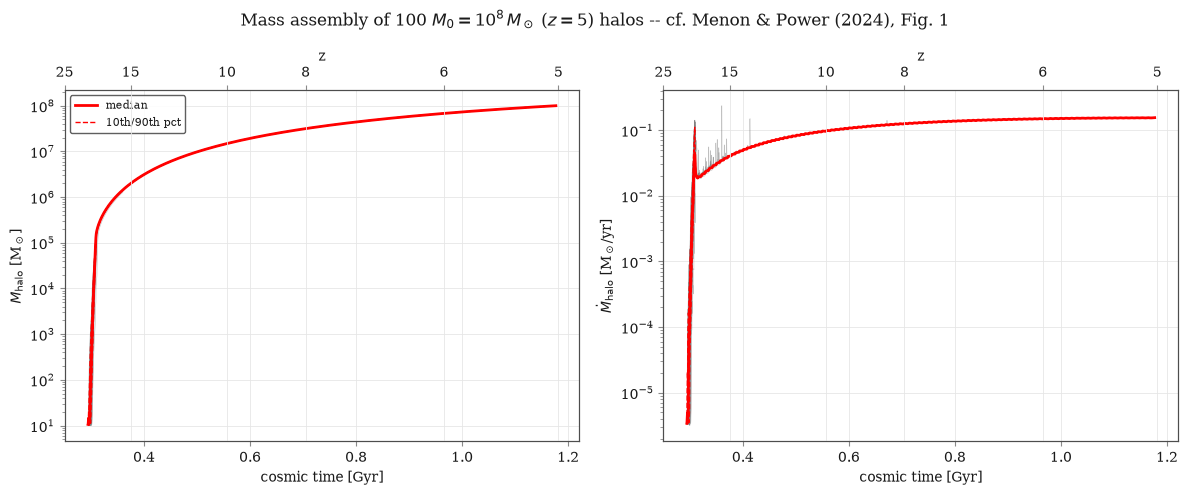

In [26]:
import warnings

import matplotlib.pyplot as plt

accretion_rate_per_yr = np.gradient(mass_chron_msun, t_chron, axis=1) / 1e9  # Msun/yr

# Mask each halo's frozen, below-resolution leading segment (see markdown above):
# find the first chronological index where its mass departs from the initial,
# resolution-limited value it's held at until then.
onset_idx = np.array(
    [
        np.argmax(mass_chron_msun[i] != mass_chron_msun[i, 0])
        for i in range(N_HALOS_MP24)
    ]
)
resolved_mask = np.zeros_like(mass_chron_msun, dtype=bool)
for i in range(N_HALOS_MP24):
    resolved_mask[i, onset_idx[i] :] = True

mass_masked = np.where(resolved_mask, mass_chron_msun, np.nan)
rate_masked = np.where(resolved_mask, np.abs(accretion_rate_per_yr), np.nan)

with warnings.catch_warnings(), np.errstate(invalid="ignore"):
    warnings.simplefilter("ignore", category=RuntimeWarning)
    mass_p10, mass_p50, mass_p90 = np.nanpercentile(mass_masked, [10, 50, 90], axis=0)
    rate_p10, rate_p50, rate_p90 = np.nanpercentile(rate_masked, [10, 50, 90], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for i in range(N_HALOS_MP24):
    ax.plot(t_chron, mass_masked[i], color="grey", lw=0.4, alpha=0.5)
ax.plot(t_chron, mass_p50, color="red", lw=2, label="median")
ax.plot(t_chron, mass_p10, color="red", lw=1, ls="--", label="10th/90th pct")
ax.plot(t_chron, mass_p90, color="red", lw=1, ls="--")
ax.set_yscale("log")
ax.set_xlabel("cosmic time [Gyr]")
ax.set_ylabel(r"$M_{\rm halo}$ [M$_\odot$]")
ax.legend(fontsize=8)

ax = axes[1]
for i in range(N_HALOS_MP24):
    ax.plot(t_chron, rate_masked[i], color="grey", lw=0.4, alpha=0.5)
ax.plot(t_chron, rate_p50, color="red", lw=2)
ax.plot(t_chron, rate_p10, color="red", lw=1, ls="--")
ax.plot(t_chron, rate_p90, color="red", lw=1, ls="--")
ax.set_yscale("log")
ax.set_xlabel("cosmic time [Gyr]")
ax.set_ylabel(r"$\dot{M}_{\rm halo}$ [M$_\odot$/yr]")

for ax in axes:
    z_ticks = np.array([25, 15, 10, 8, 6, 5])
    t_ticks = cosmo_data_mp24.cosmic_time_at_z(z_ticks) * T_RAW_TO_GYR
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(t_ticks)
    ax_top.set_xticklabels([str(zt) for zt in z_ticks])
    ax_top.set_xlabel("z")

fig.suptitle(
    r"Mass assembly of 100 $M_0=10^8\,M_\odot$ ($z=5$) halos -- cf. Menon & Power (2024), Fig. 1"
)
plt.tight_layout()
plt.show()

## 10. The Zhang & Hui (2006) exact-rate backend

`ZhangHuiMergerTree` is the barrier-agnostic counterpart to `PCHMergerTree`:
instead of PCH08's fitted `(G0, gamma1, gamma2)` branching rate, it samples
progenitor masses directly from the exact first-crossing distribution
(`foraois.first_crossing`), evaluated against `collapse.delta_c(M, z, model,
cosmo_data)`. Same `CosmoData`, same config, same tree-of-dicts/array
shapes -- it's a drop-in alternative rate calculation, not a different tool.

`build_tree` mirrors `PCHMergerTree.build_tree` exactly (§2 above), so the
same `plot_merger_history` works unchanged.

80 recorded branching events


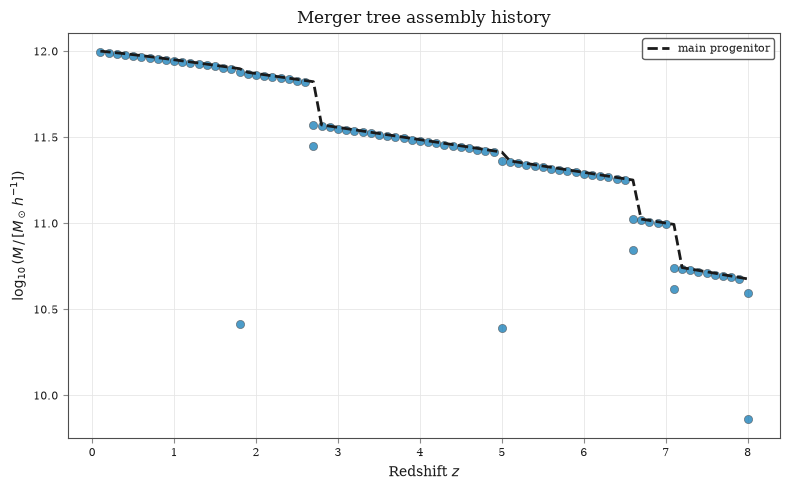

In [27]:
import warnings

from foraois.zhang_hui_trees import ZhangHuiMergerTree

# build_tree uses first_crossing_step's O(N_grid^2) solver per step; a
# grid resolution comfortable for a notebook run (rather than production
# accuracy) can under-resolve the first-crossing distribution at this
# baseline (see first_crossing_step's own grid-resolution warning) --
# expected here, not a bug.
zh_tree_generator = ZhangHuiMergerTree(cosmo_data, run_params, model="cdm", rng=np.random.default_rng(42), N_grid=100)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="first_crossing_step's grid spacing.*")
    zh_tree = zh_tree_generator.build_tree(M0=M0, z0=z0, z_max=z_max, M_res=M_res, dz=dz)
print(f"{len(zh_tree)} recorded branching events")

plot.plot_merger_history(zh_tree, file_name=None)


`build_forest_numpy` mirrors `PCHMergerTree.build_forest_numpy` too (§3
above): same `(mass_history, split_events, z_steps, smooth_accretion,
merger_mass)` return shape, so `plot_forest_summary` works unchanged.

mass_history shape: (10000, 600)


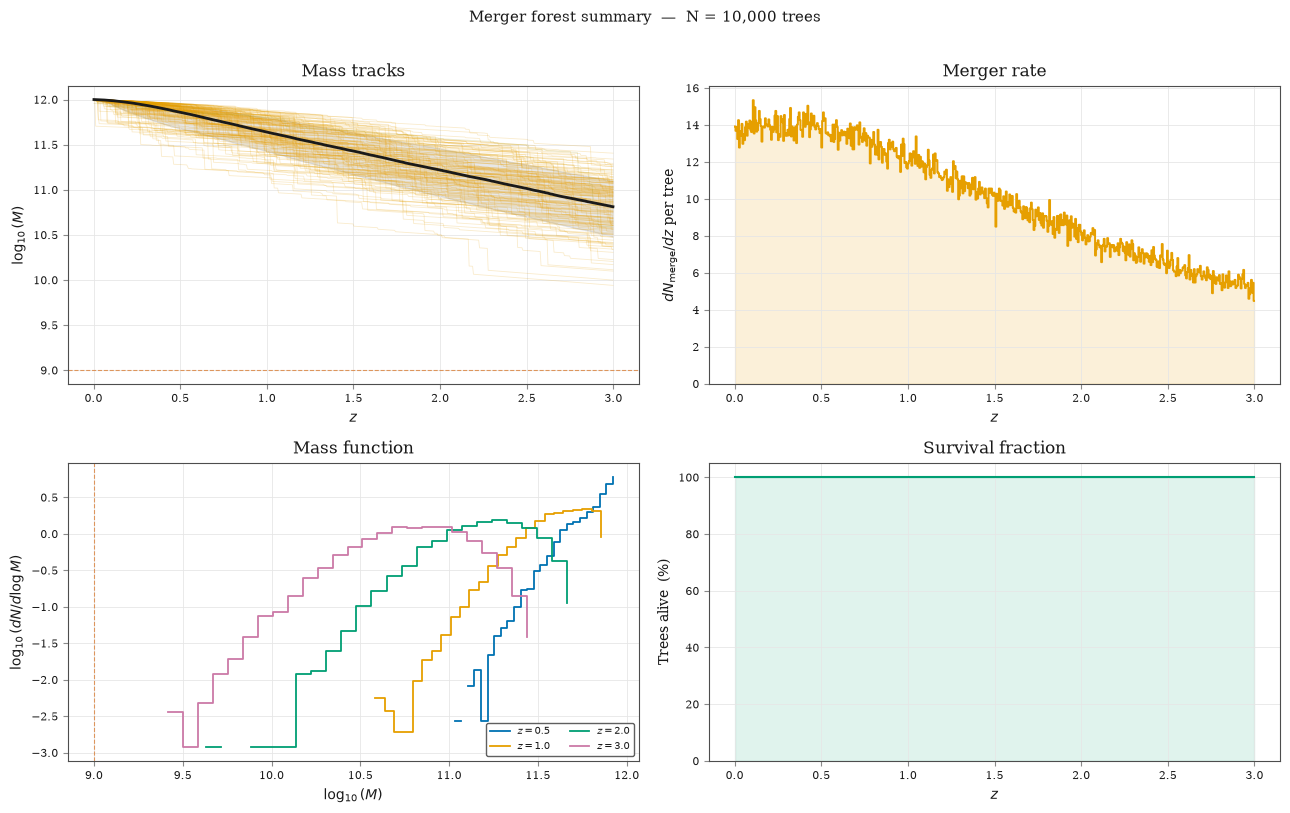

In [28]:
N_zh = 10_000
M0_array_zh = np.full(N_zh, 1.0e12)

zh_mass_history, zh_split_events, zh_z_steps, zh_smooth_accretion, zh_merger_mass = (
    zh_tree_generator.build_forest_numpy(
        M0_array=M0_array_zh,
        z0=0.0,
        z_max=3.0,
        M_res=1.0e9,
        dz=0.005,
    )
)
print(f"mass_history shape: {zh_mass_history.shape}")

plot.plot_forest_summary(
    zh_mass_history,
    zh_split_events,
    zh_z_steps,
    M_res=1.0e9,
    n_show=150,
    file_name=None,
)

## 11. PCH08 vs. Zhang-Hui: how much do the two rate calculations disagree?

N23 explicitly defer recalibrating their unconstrained (exact-rate) trees
against N-body/PCH08 (see `ROADMAP.md`), so the two backends are not
expected to agree exactly. This runs matched forests of both, at fixed
`(M0, z0, z_max, M_res, dz)`, and compares survival fraction and the
surviving trees' final main-progenitor mass distribution (same comparison
as `scripts/validate_zhang_hui_vs_pch08.py`, at a smaller `n_trees` for
notebook speed).

In [29]:
from foraois.pch_trees import PCHMergerTree

n_compare = 5_000
M0_cmp, M_res_cmp, z0_cmp, z_max_cmp, dz_cmp = 1.0e12, 1.0e10, 0.0, 1.0, 0.2
M0_array_cmp = np.full(n_compare, M0_cmp)

pch_tree_cmp = PCHMergerTree(cosmo_data, run_params)
zh_tree_cmp = ZhangHuiMergerTree(cosmo_data, run_params, model="cdm", rng=np.random.default_rng(1))

np.random.seed(1)  # PCHMergerTree.build_forest_numpy uses the global np.random state
pch_mh_cmp, *_ = pch_tree_cmp.build_forest_numpy(M0_array_cmp, z0_cmp, z_max_cmp, M_res_cmp, dz_cmp)
zh_mh_cmp, *_ = zh_tree_cmp.build_forest_numpy(M0_array_cmp, z0_cmp, z_max_cmp, M_res_cmp, dz_cmp)

pch_alive = pch_mh_cmp[:, -1][pch_mh_cmp[:, -1] > 0]
zh_alive = zh_mh_cmp[:, -1][zh_mh_cmp[:, -1] > 0]
mean_mass_discrepancy_pct = (zh_alive.mean() / pch_alive.mean() - 1.0) * 100

print(f"PCH08:      fraction alive={( pch_mh_cmp[:, -1] > 0).mean():.4f}, mean surviving mass={pch_alive.mean():.4e}")
print(f"Zhang-Hui:  fraction alive={(zh_mh_cmp[:, -1] > 0).mean():.4f}, mean surviving mass={zh_alive.mean():.4e}")
print(f"Mean-mass difference: {mean_mass_discrepancy_pct:+.2f}%")

PCH08:      fraction alive=1.0000, mean surviving mass=5.7233e+11
Zhang-Hui:  fraction alive=1.0000, mean surviving mass=5.0369e+11
Mean-mass difference: -11.99%


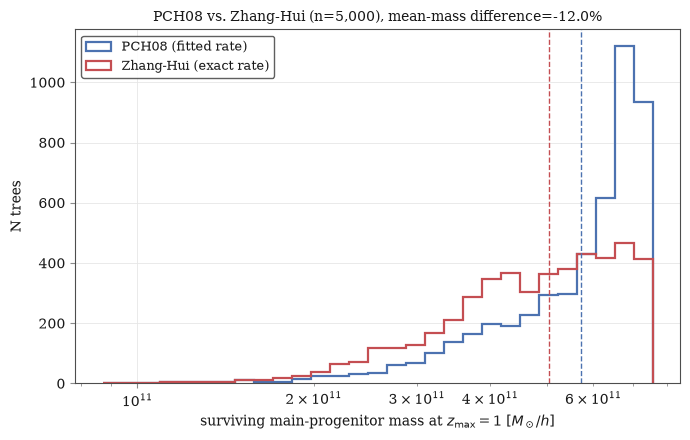

In [30]:
bins = np.logspace(
    np.log10(min(pch_alive.min(), zh_alive.min())),
    np.log10(max(pch_alive.max(), zh_alive.max())),
    30,
)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(pch_alive, bins=bins, histtype="step", lw=1.6, color="#4C72B0", label="PCH08 (fitted rate)")
ax.hist(zh_alive, bins=bins, histtype="step", lw=1.6, color="#C44E52", label="Zhang-Hui (exact rate)")
ax.axvline(pch_alive.mean(), color="#4C72B0", ls="--", lw=1)
ax.axvline(zh_alive.mean(), color="#C44E52", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel(rf"surviving main-progenitor mass at $z_{{\rm max}}={z_max_cmp:g}$ [$M_\odot/h$]")
ax.set_ylabel("N trees")
ax.set_title(f"PCH08 vs. Zhang-Hui (n={n_compare:,}), mean-mass difference={mean_mass_discrepancy_pct:+.1f}%", fontsize=10)
ax.legend(fontsize=9)
fig.tight_layout()

## 12. Brownian-bridge-constrained trees (Nadler et al. 2023)

`build_constrained_tree` grows a branch that is *guaranteed* to pass
through a chosen `(M1, z1)` -- useful for building trees conditioned on a
known progenitor, e.g. "halos that had mass $M_1$ at redshift $z_1$". It
grafts a constrained (Brownian-bridge) branch from `(M0, z0)` to `(M1,
z1)` onto ordinary unconstrained `ZhangHuiMergerTree` sampling for the
continuation beyond `z1`, returning the same tree-of-dicts shape as
`build_tree` (see `zhang_hui_constrained_trees.py`'s docstrings for the
full algorithm).

The plot below reproduces the qualitative check
`scripts/validate_constrained_tree_convergence.py` runs at scale: several
constrained realizations, all pinned to the same `(M1, z1)` (star marker),
against several *unconstrained* trees for comparison. A "typical" `M1`
(close to the unconstrained median at `z1`) should leave the branch's
earlier growth history looking like an ordinary unconstrained tree; a more
extreme `M1` should visibly bias it toward growing earlier.

In [31]:
import warnings

from foraois.zhang_hui_constrained_trees import build_constrained_tree


def history(tree, M0):
    zs = [0.0] + [e["redshift"] for e in tree]
    ms = [M0] + [max(e["progenitors"]) if e["progenitors"] else 0.0 for e in tree]
    return zs, ms


M0_con, M_res_con, z0_con, z1_con, z_max_con, dz_con = 1.0e12, 1.0e10, 0.0, 1.0, 3.0, 0.2
n_show = 10

# N_grid=60 (comfortable for a notebook run, not production accuracy)
# triggers first_crossing_step's own grid-resolution warning here --
# expected, not a bug (see §10's build_tree cell).
warnings.filterwarnings("ignore", message="first_crossing_step's grid spacing.*")

rng_uncon = np.random.default_rng(7)
zh_tree_con = ZhangHuiMergerTree(cosmo_data, run_params, model="cdm", rng=rng_uncon, N_grid=60)

unconstrained_at_z1 = []
unconstrained_histories = []
for _ in range(60):
    tree = zh_tree_con.build_tree(M0_con, z0_con, z1_con, M_res_con, dz=dz_con)
    zs = [0.0] + [e["redshift"] for e in tree]
    ms = [M0_con] + [max(e["progenitors"]) for e in tree]
    unconstrained_at_z1.append(float(np.interp(z1_con, zs, ms)))
    unconstrained_histories.append(history(tree, M0_con))

M1_con = float(np.median(unconstrained_at_z1))
print(f"Constraining to a 'typical' M1={M1_con:.3e} Msun/h at z1={z1_con}")

rng_con = np.random.default_rng(8)
constrained_histories = [
    history(
        build_constrained_tree(
            M0_con, z0_con, M1_con, z1_con, z_max_con, M_res_con, cosmo_data,
            model="cdm", dS=0.05, rng=rng_con, N_grid=60, dz=dz_con,
        ),
        M0_con,
    )
    for _ in range(n_show)
]


Constraining to a 'typical' M1=8.149e+11 Msun/h at z1=1.0


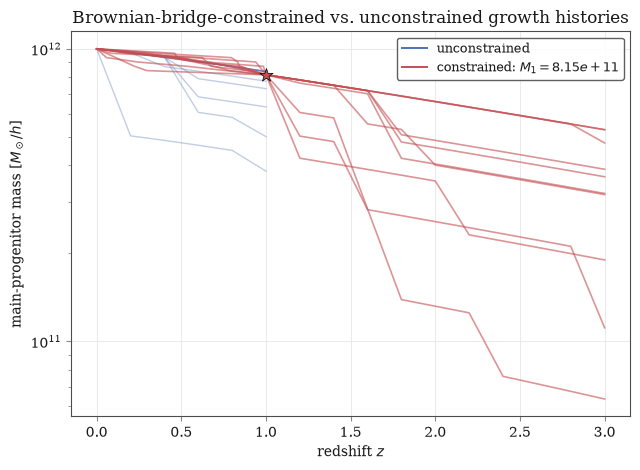

In [32]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
for zs, ms in unconstrained_histories[:n_show]:
    ax.plot(zs, ms, color="#4C72B0", alpha=0.35, lw=1.0)
ax.plot([], [], color="#4C72B0", label="unconstrained")

for zs, ms in constrained_histories:
    ax.plot(zs, ms, color="#C44E52", alpha=0.6, lw=1.2)
ax.plot([], [], color="#C44E52", label=f"constrained: $M_1={M1_con:.2e}$")
ax.scatter([z1_con], [M1_con], color="#C44E52", zorder=5, marker="*", s=100, edgecolor="k", linewidth=0.5)

ax.set_yscale("log")
ax.set_xlabel("redshift $z$")
ax.set_ylabel(r"main-progenitor mass [$M_\odot/h$]")
ax.set_title("Brownian-bridge-constrained vs. unconstrained growth histories")
ax.legend(fontsize=9)
fig.tight_layout()

## Next steps

- `tests/test_pch_validation.py` and `tests/test_zhang_hui_validation.py`
  run the same kind of checks as §5 and §11 across a range of mass ratios
  and step sizes as part of the regression suite.
- Every function used above only touches `sigma(M)`/`alpha(M)` through
  `CosmoData`'s generic lookups, so the WDM/FDM examples in §6-8 apply to
  `ZhangHuiMergerTree` unchanged too.
- See `ROADMAP.md` for what's still open: SIDM support, a WDM-specific
  rate refit, FDM's real mass-dependent collapse barrier, secondary
  branches on constrained trees, and a numba backend for the exact
  Zhang-Hui algorithm.